# Analyse Exploratoire - Mouvement des Joueurs pendant le Ballon en L'air

Ce notebook contient l'analyse exploratoire des données NFL pour comprendre le mouvement des joueurs pendant que le ballon est en l'air.


In [5]:
import pandas as pd


ModuleNotFoundError: No module named 'pandas'

In [4]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Configuration pour les graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


ModuleNotFoundError: No module named 'pandas'

## 1. Chargement des données


In [9]:
# Chemin vers les données
data_path = Path('.')
train_path = data_path / 'train'

# Charger les données supplémentaires
supp_data = pd.read_csv('supplementary_data.csv')
print(f"Nombre de lignes dans supplementary_data: {len(supp_data)}")
print(f"Colonnes: {supp_data.columns.tolist()}")
supp_data.head()


Nombre de lignes dans supplementary_data: 18009
Colonnes: ['game_id', 'season', 'week', 'game_date', 'game_time_eastern', 'home_team_abbr', 'visitor_team_abbr', 'play_id', 'play_description', 'quarter', 'game_clock', 'down', 'yards_to_go', 'possession_team', 'defensive_team', 'yardline_side', 'yardline_number', 'pre_snap_home_score', 'pre_snap_visitor_score', 'play_nullified_by_penalty', 'pass_result', 'pass_length', 'offense_formation', 'receiver_alignment', 'route_of_targeted_receiver', 'play_action', 'dropback_type', 'dropback_distance', 'pass_location_type', 'defenders_in_the_box', 'team_coverage_man_zone', 'team_coverage_type', 'penalty_yards', 'pre_penalty_yards_gained', 'yards_gained', 'expected_points', 'expected_points_added', 'pre_snap_home_team_win_probability', 'pre_snap_visitor_team_win_probability', 'home_team_win_probability_added', 'visitor_team_win_probility_added']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13112\2099403868.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  supp_data = pd.read_csv('supplementary_data.csv')


,game_id,season,week,game_date,game_time_eastern,home_team_abbr,visitor_team_abbr,play_id,play_description,quarter,...,team_coverage_type,penalty_yards,pre_penalty_yards_gained,yards_gained,expected_points,expected_points_added,pre_snap_home_team_win_probability,pre_snap_visitor_team_win_probability,home_team_win_probability_added,visitor_team_win_probility_added
0,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,3461,(10:46) (Shotgun) J.Goff pass deep left to J.R...,4,...,COVER_2_ZONE,NaN,18,18,-0.664416,2.945847,0.834296,0.165704,-0.081149,0.081149
1,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,461,(7:30) J.Goff pass short right to J.Reynolds t...,1,...,COVER_6_ZONE,NaN,21,21,1.926131,1.345633,0.544618,0.455382,-0.029415,0.029415
2,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1940,(:09) (Shotgun) J.Goff pass incomplete deep ri...,2,...,COVER_2_ZONE,NaN,0,0,0.281891,-0.081964,0.771994,0.228006,0.000791,-0.000791
3,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1711,"(:45) (No Huddle, Shotgun) P.Mahomes pass deep...",2,...,COVER_2_ZONE,NaN,26,26,3.452352,2.342947,0.663187,0.336813,0.041843,-0.041843
4,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1588,(1:54) (Shotgun) P.Mahomes pass incomplete dee...,2,...,COVER_4_ZONE,NaN,0,0,1.921525,-0.324035,0.615035,0.384965,0.000061,-0.000061


In [10]:
# Charger un fichier d'entrée pour voir la structure
input_file = train_path / 'input_2023_w01.csv'
df_input = pd.read_csv(input_file)
print(f"Taille du fichier d'entrée: {len(df_input)} lignes")
print(f"\nColonnes disponibles:")
print(df_input.columns.tolist())
df_input.head(10)


Taille du fichier d'entrée: 285714 lignes

Colonnes disponibles:
['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y']


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22
5,2023090700,101,False,54527,6,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.44,36.88,0.60,0.87,106.89,247.67,21,63.259998,-0.22
6,2023090700,101,False,54527,7,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.51,36.86,0.76,0.64,103.87,247.67,21,63.259998,-0.22
7,2023090700,101,False,54527,8,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.60,36.85,0.91,0.92,100.97,246.69,21,63.259998,-0.22
8,2023090700,101,False,54527,9,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.71,36.83,1.10,1.31,98.15,247.39,21,63.259998,-0.22
9,2023090700,101,False,54527,10,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.84,36.81,1.32,1.71,96.73,243.01,21,63.259998,-0.22


In [11]:
# Vérifier les joueurs à prédire
joueurs_a_predire = df_input[df_input['player_to_predict'] == True]
print(f"Nombre de joueurs à prédire dans ce fichier: {joueurs_a_predire['nfl_id'].nunique()}")
print(f"Nombre total de frames pour ces joueurs: {len(joueurs_a_predire)}")


Nombre de joueurs à prédire dans ce fichier: 563
Nombre total de frames pour ces joueurs: 76399


## 2. Analyse des statistiques de base


In [16]:
# Statistiques descriptives sur les données d'entrée
colonnes_numeriques = ['x', 'y', 's', 'a', 'dir', 'o', 'ball_land_x', 'ball_land_y']
stats = df_input[colonnes_numeriques].describe()
print("Statistiques descriptives:")
stats


Statistiques descriptives:


,x,y,s,a,dir,o,ball_land_x,ball_land_y
count,285714.000000,285714.000000,285714.000000,285714.000000,285714.000000,285714.000000,285714.000000,285714.000000
mean,60.466355,26.751004,3.041966,2.126249,177.926268,181.198227,60.851685,26.215487
std,24.007917,10.035753,2.231126,1.430355,100.934248,98.972312,25.759902,15.275341
min,1.210000,0.970000,0.000000,0.000000,0.000000,0.000000,1.330000,-1.690000
25%,41.630000,18.900000,1.120000,1.010000,89.530000,89.930000,41.730000,12.640000
50%,58.810000,26.710000,2.730000,1.920000,173.365000,182.230000,59.060001,25.450001
75%,78.520000,34.530000,4.650000,3.050000,269.580000,271.320000,78.970001,39.250000
max,119.860000,52.430000,12.530000,17.120000,359.990000,359.990000,119.779999,57.330002


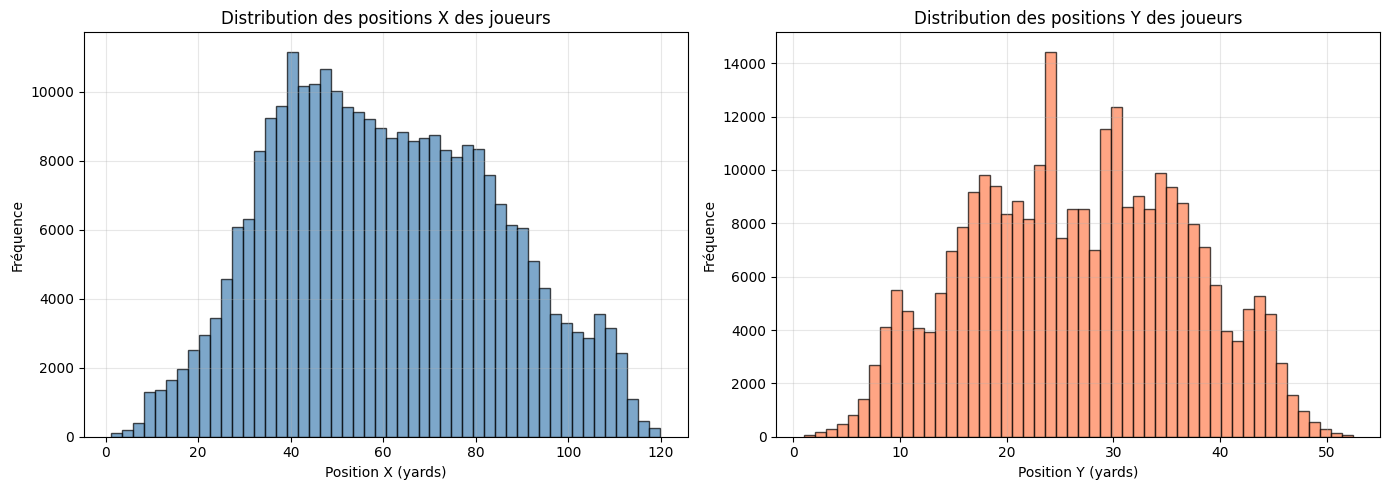

In [17]:
# Distribution des positions des joueurs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_input['x'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Position X (yards)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des positions X des joueurs')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_input['y'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Position Y (yards)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des positions Y des joueurs')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Analyse de la vitesse et de l'accélération


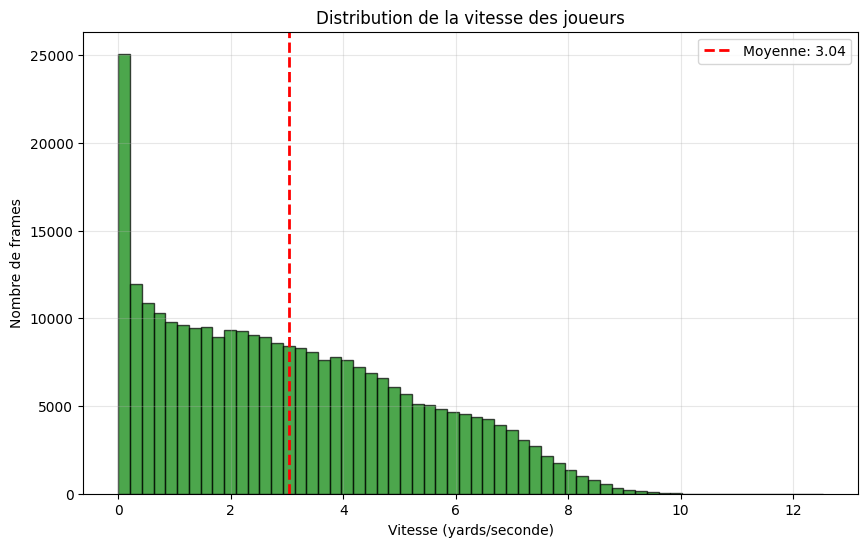

In [18]:
# Graphique de la vitesse
plt.figure(figsize=(10, 6))
plt.hist(df_input['s'], bins=60, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Vitesse (yards/seconde)')
plt.ylabel('Nombre de frames')
plt.title('Distribution de la vitesse des joueurs')
plt.axvline(df_input['s'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df_input["s"].mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


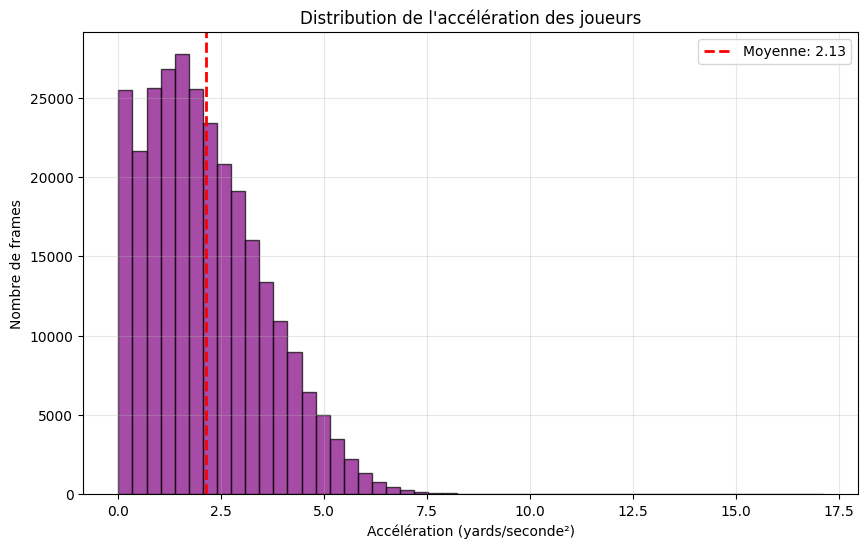

In [19]:
# Graphique de l'accélération
plt.figure(figsize=(10, 6))
plt.hist(df_input['a'], bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Accélération (yards/seconde²)')
plt.ylabel('Nombre de frames')
plt.title('Distribution de l\'accélération des joueurs')
plt.axvline(df_input['a'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df_input["a"].mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


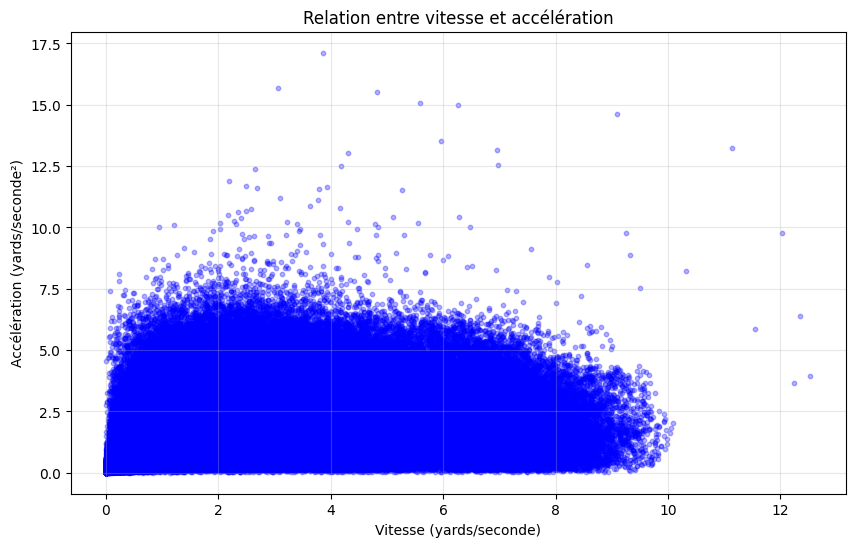

In [20]:
# Relation entre vitesse et accélération
plt.figure(figsize=(10, 6))
plt.scatter(df_input['s'], df_input['a'], alpha=0.3, s=10, color='blue')
plt.xlabel('Vitesse (yards/seconde)')
plt.ylabel('Accélération (yards/seconde²)')
plt.title('Relation entre vitesse et accélération')
plt.grid(True, alpha=0.3)
plt.show()


## 4. Analyse par rôle des joueurs


Distribution des rôles:
player_role
Defensive Coverage    155397
Other Route Runner     84063
Targeted Receiver      23151
Passer                 23103
Name: count, dtype: int64


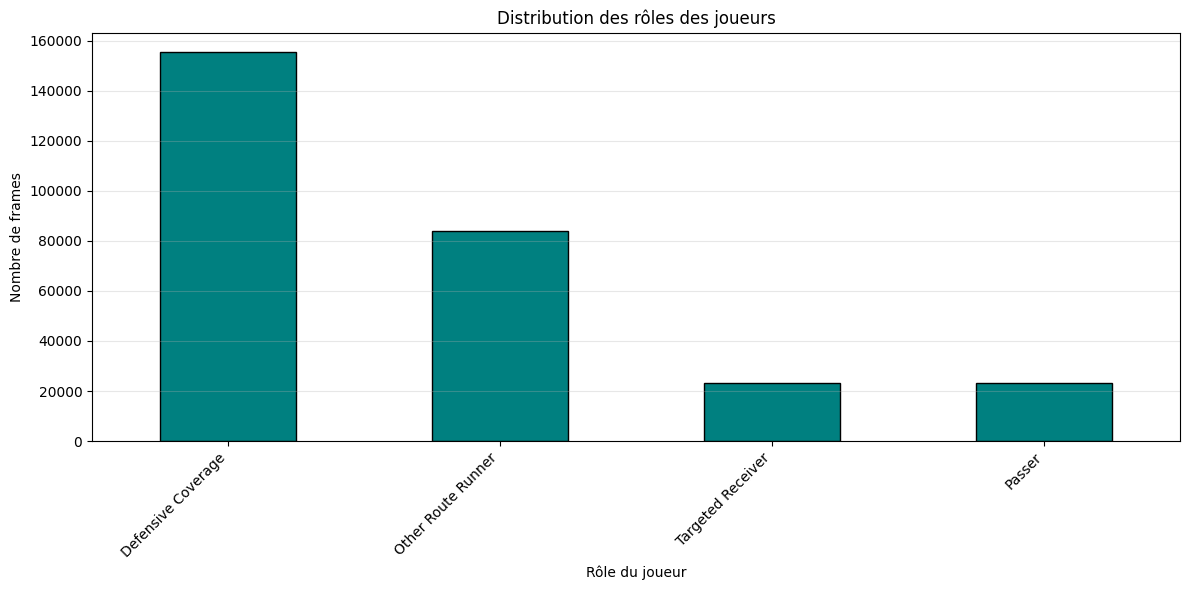

In [21]:
# Distribution des rôles
roles = df_input['player_role'].value_counts()
print("Distribution des rôles:")
print(roles)

plt.figure(figsize=(12, 6))
roles.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Rôle du joueur')
plt.ylabel('Nombre de frames')
plt.title('Distribution des rôles des joueurs')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


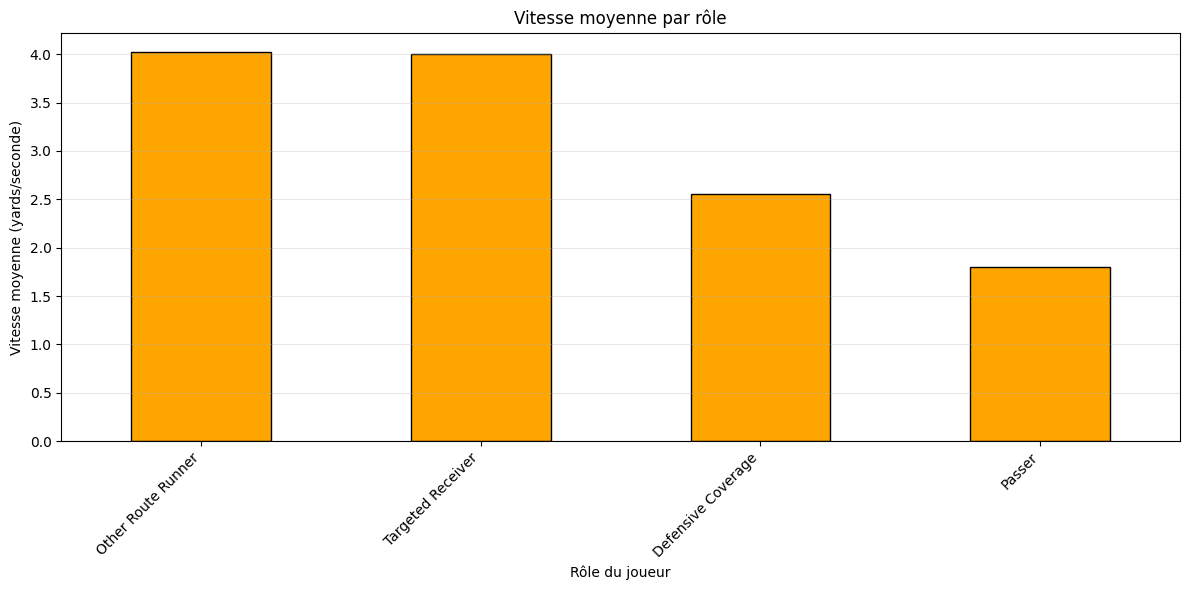

In [22]:
# Vitesse moyenne par rôle
vitesse_par_role = df_input.groupby('player_role')['s'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
vitesse_par_role.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Rôle du joueur')
plt.ylabel('Vitesse moyenne (yards/seconde)')
plt.title('Vitesse moyenne par rôle')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 5. Analyse des trajectoires des joueurs à prédire


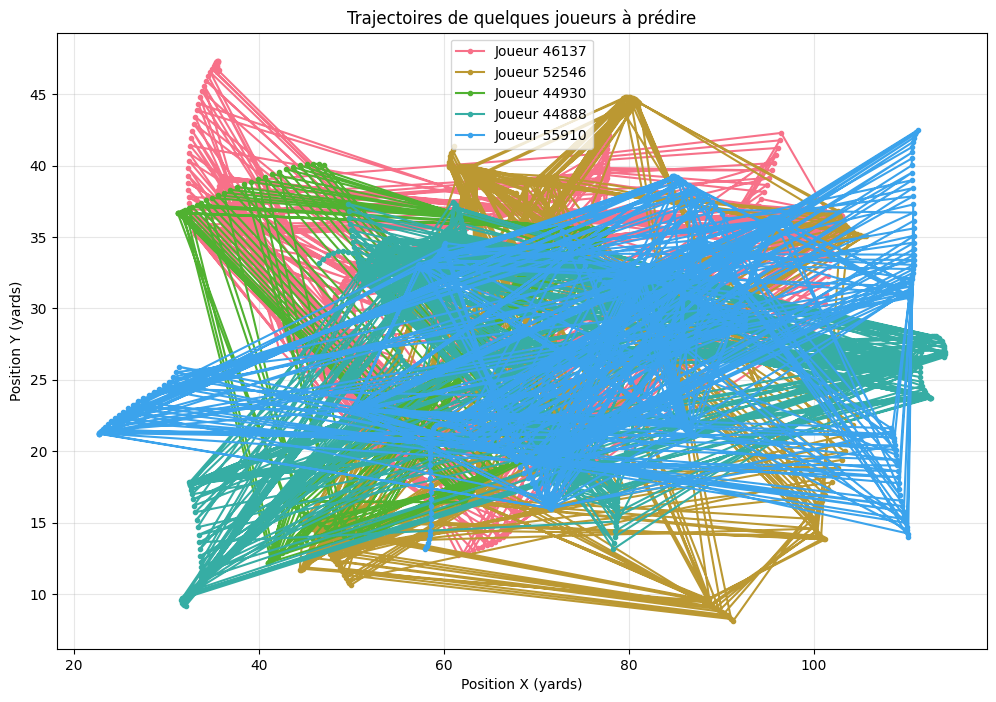

In [23]:
# Sélectionner quelques joueurs à prédire pour visualiser leurs trajectoires
joueurs_uniques = joueurs_a_predire['nfl_id'].unique()[:5]

plt.figure(figsize=(12, 8))
for nfl_id in joueurs_uniques:
    joueur_data = joueurs_a_predire[joueurs_a_predire['nfl_id'] == nfl_id].sort_values('frame_id')
    plt.plot(joueur_data['x'], joueur_data['y'], marker='o', markersize=3, linewidth=1.5, label=f'Joueur {nfl_id}')

plt.xlabel('Position X (yards)')
plt.ylabel('Position Y (yards)')
plt.title('Trajectoires de quelques joueurs à prédire')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [24]:
# Charger les données de sortie pour comparer
output_file = train_path / 'output_2023_w01.csv'
df_output = pd.read_csv(output_file)
print(f"Taille du fichier de sortie: {len(df_output)} lignes")
df_output.head()


Taille du fichier de sortie: 32088 lignes


,game_id,play_id,nfl_id,frame_id,x,y
0,2023090700,101,46137,1,56.22,17.28
1,2023090700,101,46137,2,56.63,16.88
2,2023090700,101,46137,3,57.06,16.46
3,2023090700,101,46137,4,57.48,16.02
4,2023090700,101,46137,5,57.91,15.56


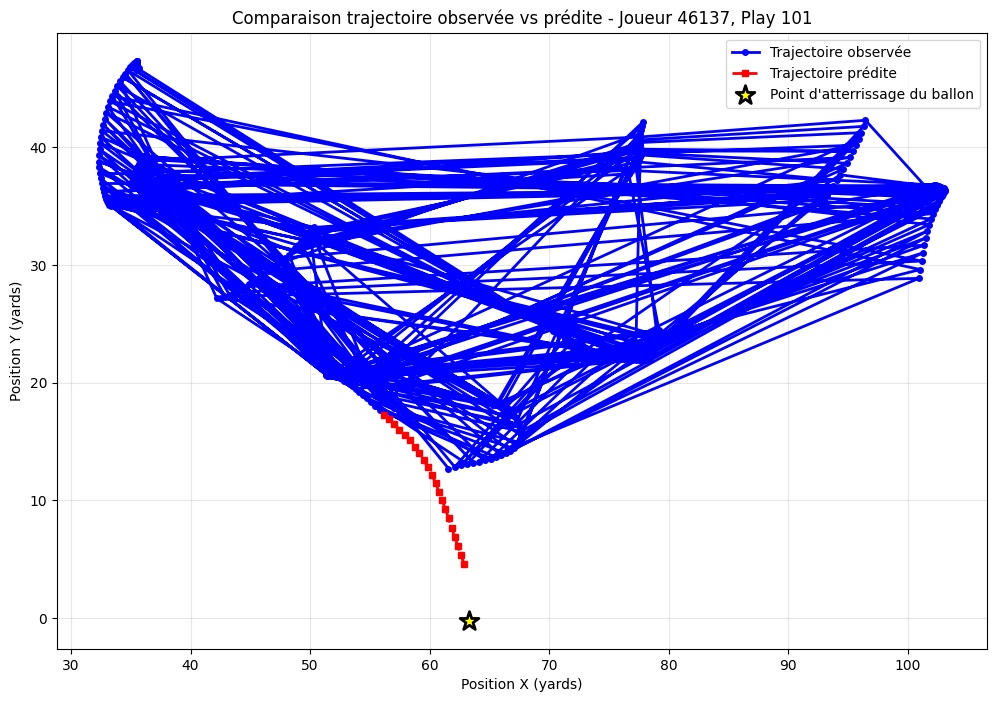

In [26]:
# Comparer trajectoire réelle vs prédite pour un joueur
nfl_id_exemple = joueurs_uniques[0]
joueur_input = joueurs_a_predire[joueurs_a_predire['nfl_id'] == nfl_id_exemple].sort_values('frame_id')
joueur_output = df_output[df_output['nfl_id'] == nfl_id_exemple].sort_values('frame_id')

# Trouver le play_id correspondant
play_id_exemple = joueur_input['play_id'].iloc[0]
joueur_output_play = joueur_output[joueur_output['play_id'] == play_id_exemple]

if len(joueur_output_play) > 0:
    plt.figure(figsize=(12, 8))
    
    # Trajectoire initiale (input)
    plt.plot(joueur_input['x'], joueur_input['y'], 'b-o', markersize=4, linewidth=2, label='Trajectoire observée')
    
    # Trajectoire prédite (output)
    plt.plot(joueur_output_play['x'], joueur_output_play['y'], 'r--s', markersize=4, linewidth=2, label='Trajectoire prédite')
    
    # Point d'atterrissage du ballon
    ball_land_x = joueur_input['ball_land_x'].iloc[0]
    ball_land_y = joueur_input['ball_land_y'].iloc[0]
    plt.scatter(ball_land_x, ball_land_y, s=200, color='yellow', marker='*', edgecolors='black', linewidths=2, label='Point d\'atterrissage du ballon', zorder=5)
    
    plt.xlabel('Position X (yards)')
    plt.ylabel('Position Y (yards)')
    plt.title(f'Comparaison trajectoire observée vs prédite - Joueur {nfl_id_exemple}, Play {play_id_exemple}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 6. Analyse des données supplémentaires


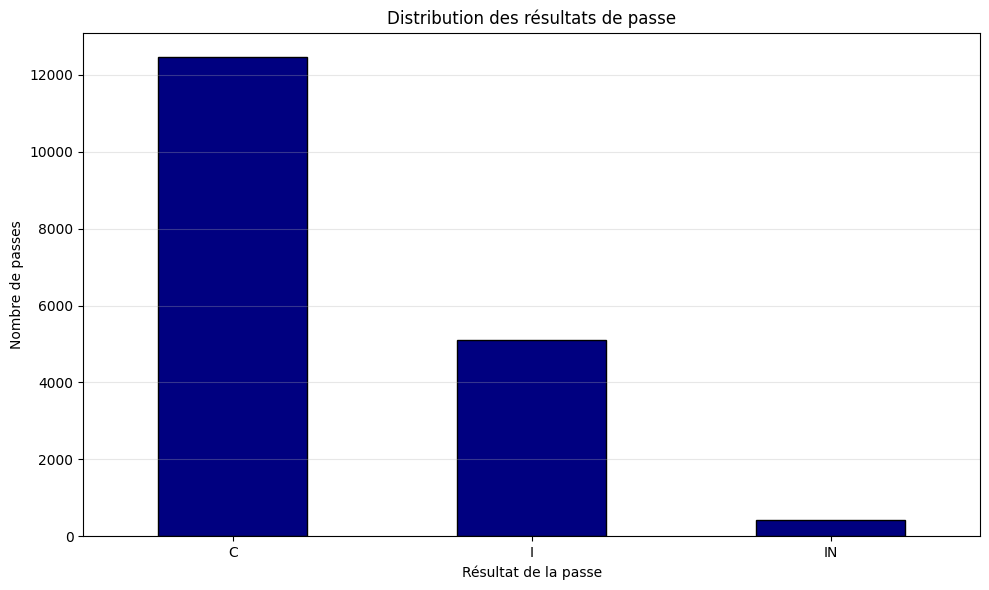

In [27]:
# Résultats des passes
resultats_passe = supp_data['pass_result'].value_counts()

plt.figure(figsize=(10, 6))
resultats_passe.plot(kind='bar', color='navy', edgecolor='black')
plt.xlabel('Résultat de la passe')
plt.ylabel('Nombre de passes')
plt.title('Distribution des résultats de passe')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


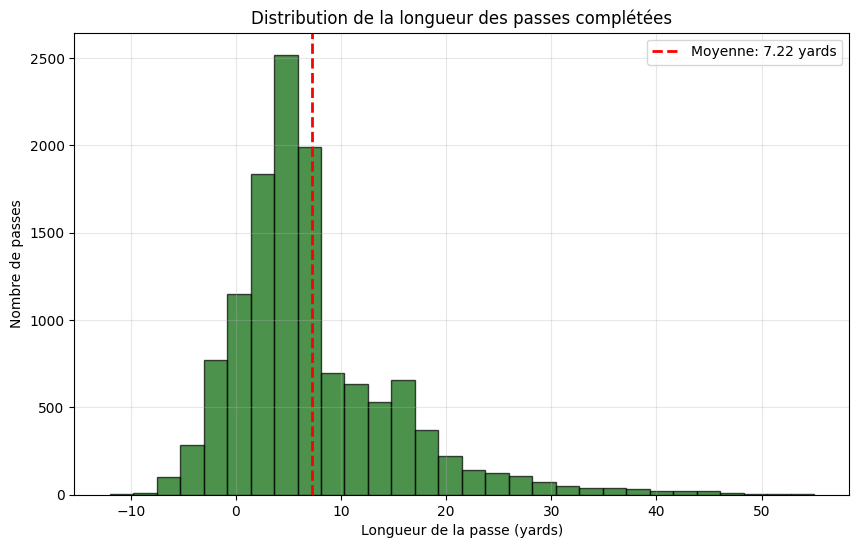

In [28]:
# Longueur des passes
passes_completes = supp_data[supp_data['pass_result'] == 'C']

plt.figure(figsize=(10, 6))
plt.hist(passes_completes['pass_length'].dropna(), bins=30, color='darkgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Longueur de la passe (yards)')
plt.ylabel('Nombre de passes')
plt.title('Distribution de la longueur des passes complétées')
plt.axvline(passes_completes['pass_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {passes_completes["pass_length"].mean():.2f} yards')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


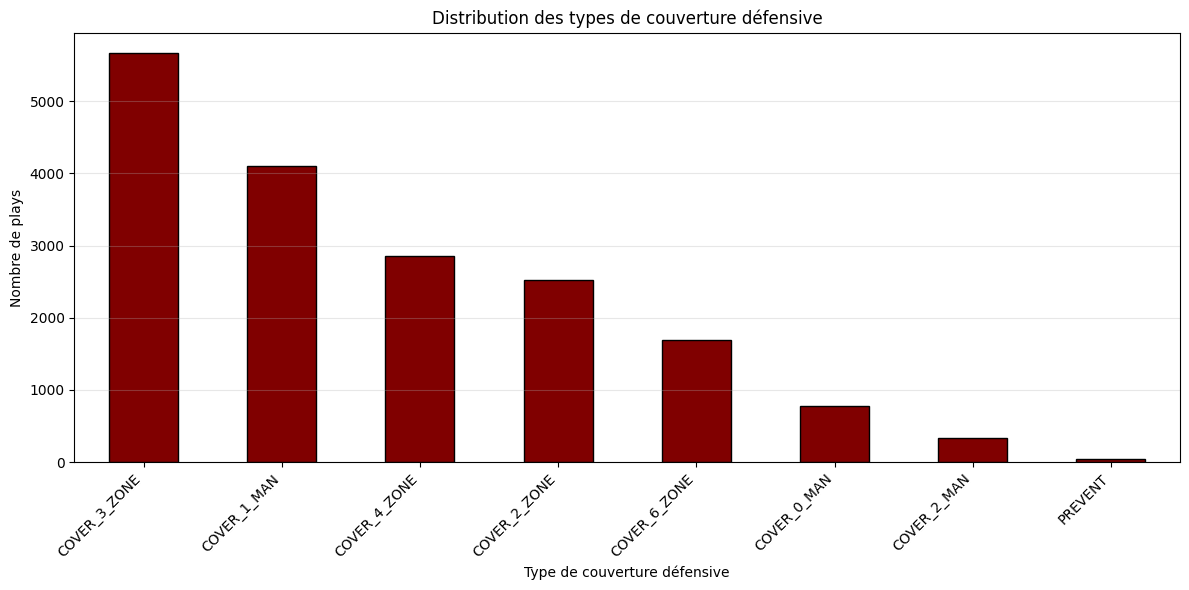

In [29]:
# Type de couverture défensive
couverture = supp_data['team_coverage_type'].value_counts()

plt.figure(figsize=(12, 6))
couverture.plot(kind='bar', color='maroon', edgecolor='black')
plt.xlabel('Type de couverture défensive')
plt.ylabel('Nombre de plays')
plt.title('Distribution des types de couverture défensive')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


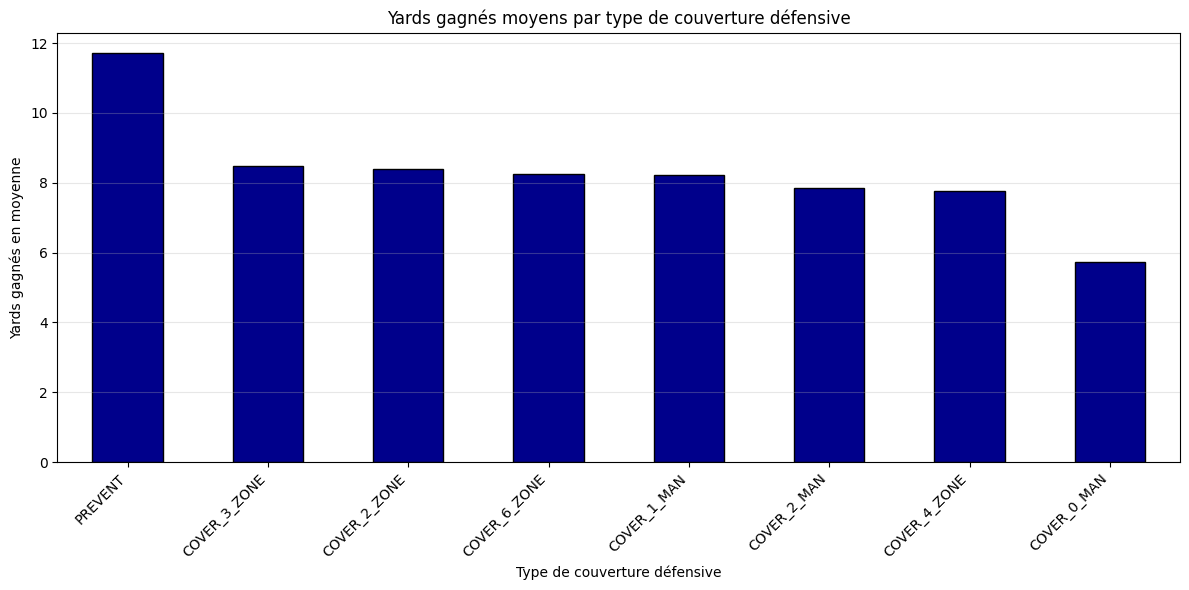

In [30]:
# Yards gagnés par type de couverture
yards_par_couverture = supp_data.groupby('team_coverage_type')['yards_gained'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
yards_par_couverture.plot(kind='bar', color='darkblue', edgecolor='black')
plt.xlabel('Type de couverture défensive')
plt.ylabel('Yards gagnés en moyenne')
plt.title('Yards gagnés moyens par type de couverture défensive')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 7. Analyse temporelle par semaine


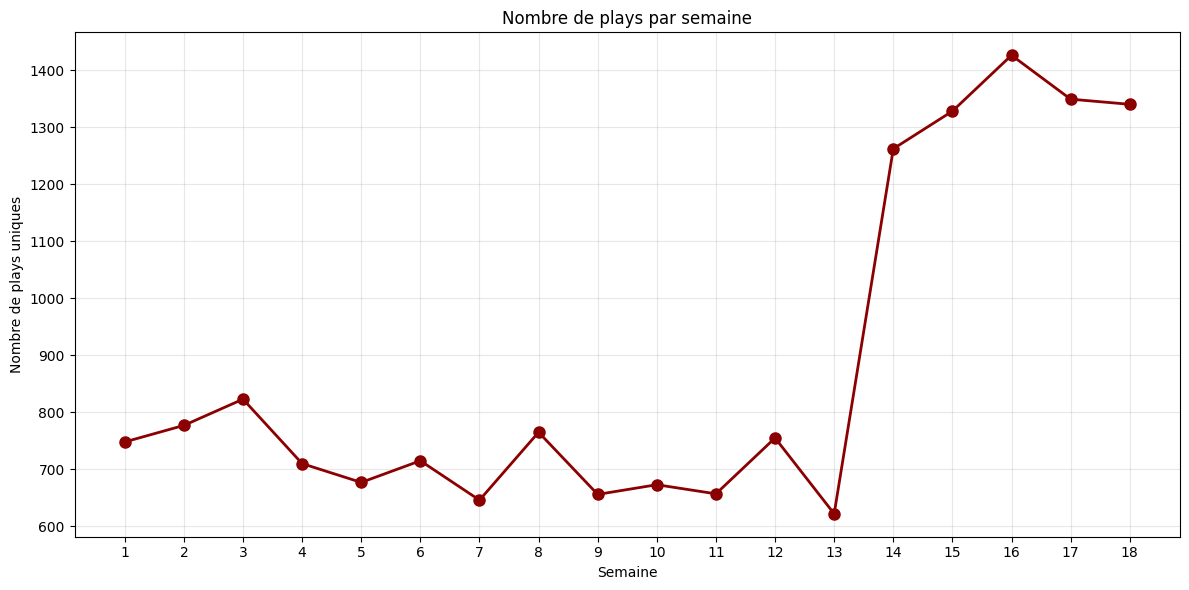

In [31]:
# Nombre de plays par semaine
plays_par_semaine = supp_data.groupby('week')['play_id'].nunique().sort_index()

plt.figure(figsize=(12, 6))
plays_par_semaine.plot(kind='line', marker='o', linewidth=2, markersize=8, color='darkred')
plt.xlabel('Semaine')
plt.ylabel('Nombre de plays uniques')
plt.title('Nombre de plays par semaine')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 19))
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13112\3043464909.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux_completion = supp_data.groupby('week').apply(lambda x: (x['pass_result'] == 'C').sum() / len(x) * 100)


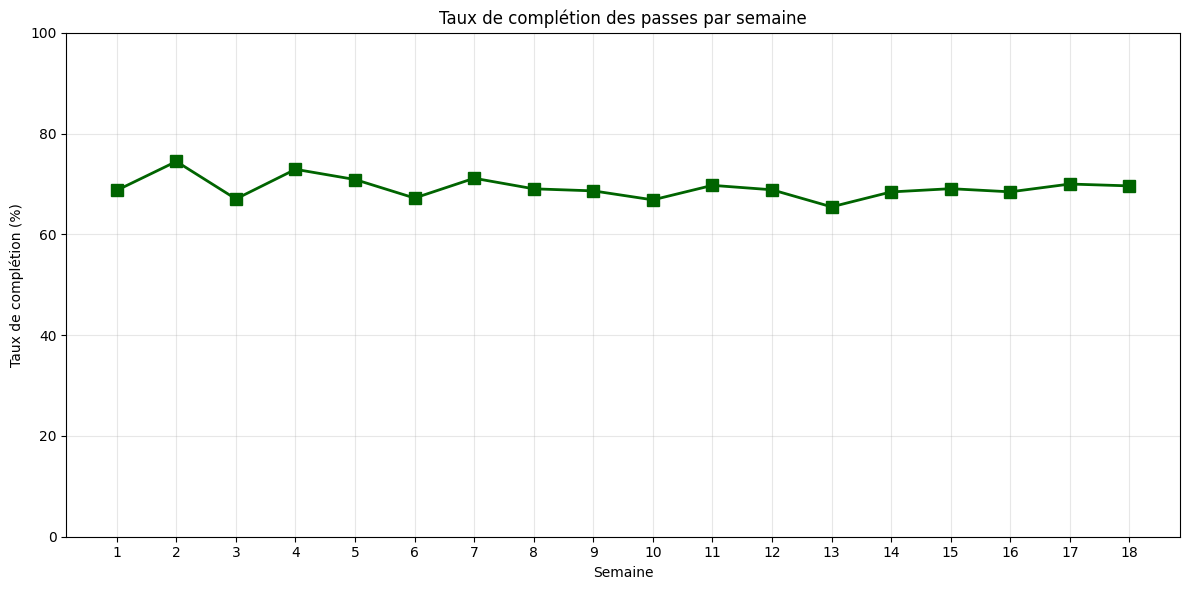

In [32]:
# Taux de complétion par semaine
taux_completion = supp_data.groupby('week').apply(lambda x: (x['pass_result'] == 'C').sum() / len(x) * 100)

plt.figure(figsize=(12, 6))
taux_completion.plot(kind='line', marker='s', linewidth=2, markersize=8, color='darkgreen')
plt.xlabel('Semaine')
plt.ylabel('Taux de complétion (%)')
plt.title('Taux de complétion des passes par semaine')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 19))
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


## 8. Analyse de la distance au point d'atterrissage


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13112\2241141972.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joueurs_a_predire['distance_ball'] = np.sqrt((joueurs_a_predire['x'] - joueurs_a_predire['ball_land_x'])**2 +


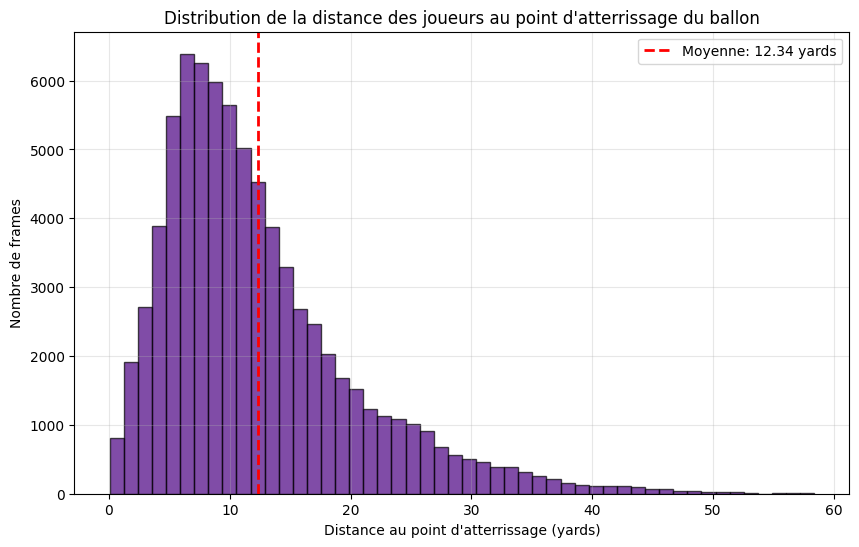

In [33]:
# Calculer la distance entre le joueur et le point d'atterrissage du ballon
df_input['distance_ball'] = np.sqrt((df_input['x'] - df_input['ball_land_x'])**2 + 
                                     (df_input['y'] - df_input['ball_land_y'])**2)

# Pour les joueurs à prédire uniquement
joueurs_a_predire['distance_ball'] = np.sqrt((joueurs_a_predire['x'] - joueurs_a_predire['ball_land_x'])**2 + 
                                             (joueurs_a_predire['y'] - joueurs_a_predire['ball_land_y'])**2)

plt.figure(figsize=(10, 6))
plt.hist(joueurs_a_predire['distance_ball'], bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.xlabel('Distance au point d\'atterrissage (yards)')
plt.ylabel('Nombre de frames')
plt.title('Distribution de la distance des joueurs au point d\'atterrissage du ballon')
plt.axvline(joueurs_a_predire['distance_ball'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Moyenne: {joueurs_a_predire["distance_ball"].mean():.2f} yards')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


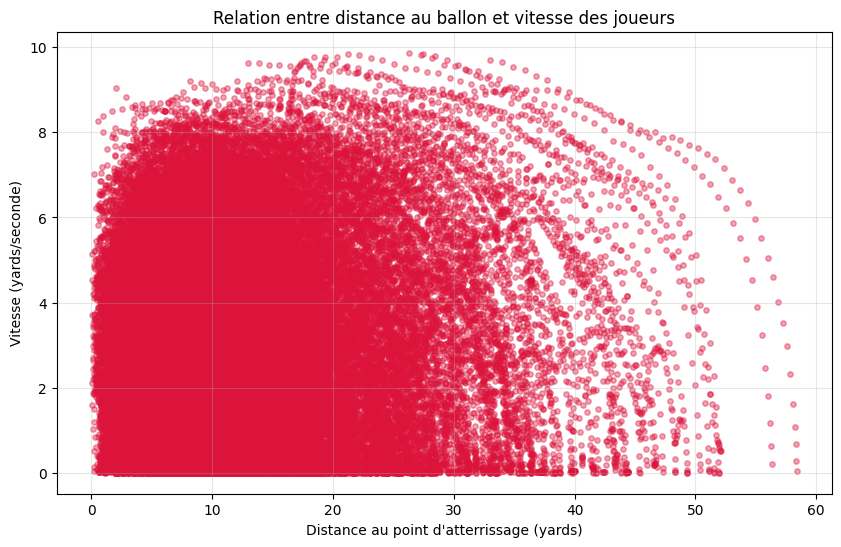

In [34]:
# Relation entre vitesse et distance au ballon
plt.figure(figsize=(10, 6))
plt.scatter(joueurs_a_predire['distance_ball'], joueurs_a_predire['s'], alpha=0.4, s=15, color='crimson')
plt.xlabel('Distance au point d\'atterrissage (yards)')
plt.ylabel('Vitesse (yards/seconde)')
plt.title('Relation entre distance au ballon et vitesse des joueurs')
plt.grid(True, alpha=0.3)
plt.show()


## 9. Analyse par quart-temps


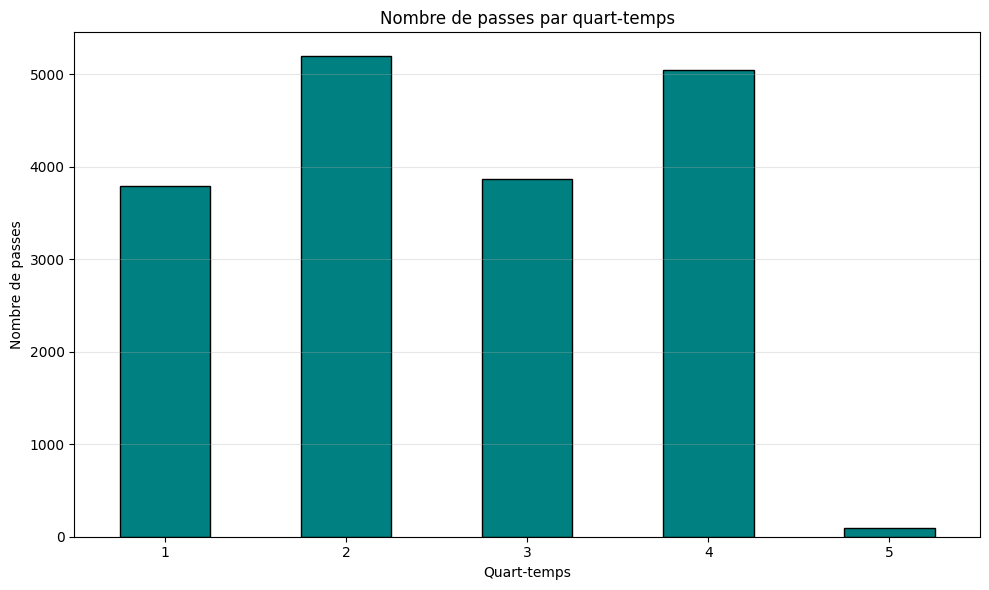

In [35]:
# Nombre de passes par quart-temps
passes_par_quart = supp_data['quarter'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
passes_par_quart.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Quart-temps')
plt.ylabel('Nombre de passes')
plt.title('Nombre de passes par quart-temps')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13112\3772659504.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion_par_quart = supp_data.groupby('quarter').apply(lambda x: (x['pass_result'] == 'C').sum() / len(x) * 100)


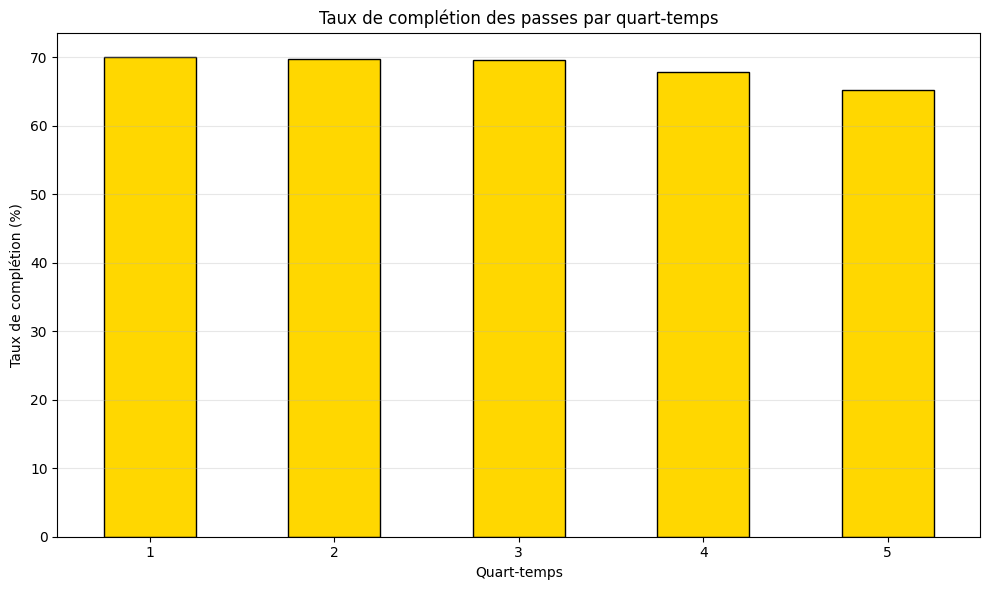

In [36]:
# Taux de complétion par quart-temps
completion_par_quart = supp_data.groupby('quarter').apply(lambda x: (x['pass_result'] == 'C').sum() / len(x) * 100)

plt.figure(figsize=(10, 6))
completion_par_quart.plot(kind='bar', color='gold', edgecolor='black')
plt.xlabel('Quart-temps')
plt.ylabel('Taux de complétion (%)')
plt.title('Taux de complétion des passes par quart-temps')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [37]:
print("=== RÉSUMÉ DE L'ANALYSE EXPLORATOIRE ===\n")
print(f"Nombre total de plays dans les données supplémentaires: {supp_data['play_id'].nunique()}")
print(f"Nombre de frames dans le fichier d'entrée analysé: {len(df_input)}")
print(f"Nombre de joueurs à prédire dans ce fichier: {joueurs_a_predire['nfl_id'].nunique()}")
print(f"\nVitesse moyenne des joueurs: {df_input['s'].mean():.2f} yards/seconde")
print(f"Accélération moyenne: {df_input['a'].mean():.2f} yards/seconde²")
print(f"\nTaux de complétion global: {(supp_data['pass_result'] == 'C').sum() / len(supp_data) * 100:.2f}%")
print(f"Longueur moyenne des passes complétées: {passes_completes['pass_length'].mean():.2f} yards")


=== RÉSUMÉ DE L'ANALYSE EXPLORATOIRE ===

Nombre total de plays dans les données supplémentaires: 4471
Nombre de frames dans le fichier d'entrée analysé: 285714
Nombre de joueurs à prédire dans ce fichier: 563

Vitesse moyenne des joueurs: 3.04 yards/seconde
Accélération moyenne: 2.13 yards/seconde²

Taux de complétion global: 69.24%
Longueur moyenne des passes complétées: 7.22 yards
